# Dataset stats (raw labels)


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from aitraf.data_ops.schema import LabelsSchema

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
LABELS_PATH = DATA_DIR / "labels.jsonl"
PLOTS_DIR = PROJECT_ROOT / "notebooks" / "data" / "dataset-stats"

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")


In [2]:
labels_df = pd.read_json(LABELS_PATH, lines=True, dtype=LabelsSchema.types)
labels_df.head()


,annotation_id,annotator,created_at,execution_explanation,execution_score,id,key_foot,lead_time,person,trick,updated_at,video
0,163,1,2025-11-09 20:54:35.712942+00:00,Too short and too slow,2,456,right,22.179,Henrikas,fs-royale,2025-12-30 15:37:52.180275+00:00,s3://aitraf/clips/25-10-31 19-46-26 5688-00.04...
1,135,1,2025-11-09 19:11:56.773045+00:00,Really short. Barely counts as grind.,1,482,right,39.935,Henrikas,mizou,2025-12-30 15:38:42.621260+00:00,s3://aitraf/clips/25-10-31 19-54-19 5689-00.08...
2,174,1,2025-11-09 20:56:51.652810+00:00,"Short, really slow. Body position feels awkward.",2,468,left,39.458,Henrikas,mizou,2025-12-30 17:57:42.338152+00:00,s3://aitraf/clips/25-10-31 19-54-19 5689-00.00...
3,141,1,2025-11-09 19:13:18.176155+00:00,Too slow and too short,2,470,right,26.775,Henrikas,fs-royale,2025-12-30 17:58:06.109619+00:00,s3://aitraf/clips/25-10-31 19-54-19 5689-00.01...
4,178,1,2025-11-09 20:57:37.265458+00:00,"Great overall, low body position",4,473,right,30.483,Max,mizou,2026-01-07 14:34:20.750184+00:00,s3://aitraf/clips/25-10-31 19-54-19 5689-00.03...


In [3]:
def save_plot(fig, name):
    path = PLOTS_DIR / f"{name}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    return path


## Trick distribution


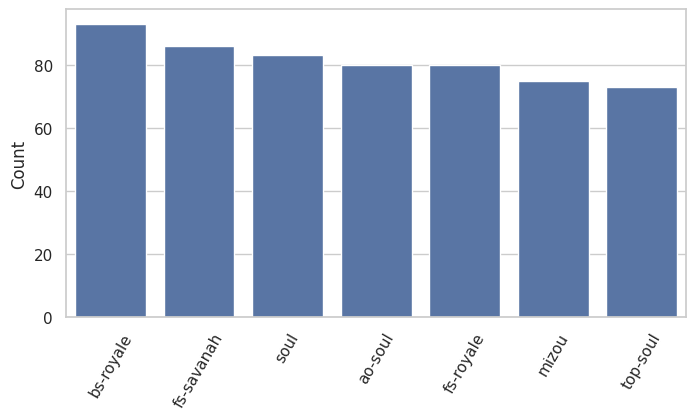

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.countplot(data=labels_df, x="trick", order=labels_df["trick"].value_counts().index, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=60)
save_plot(fig, "trick_dist")
plt.show()


## Ratings distribution


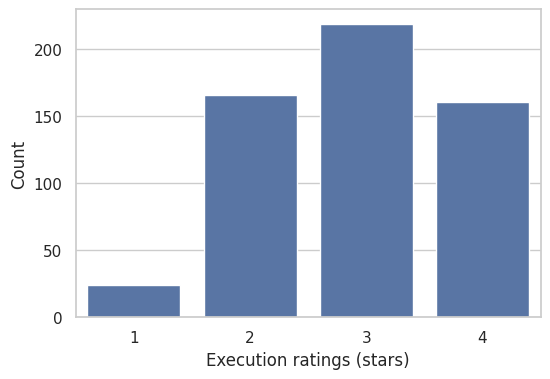

In [5]:
ratings = labels_df["execution_score"].dropna()
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x=ratings, order=sorted(ratings.unique()), ax=ax)
ax.set_xlabel("Execution ratings (stars)")
ax.set_ylabel("Count")
save_plot(fig, "ratings_dist")
plt.show()


## Person distribution


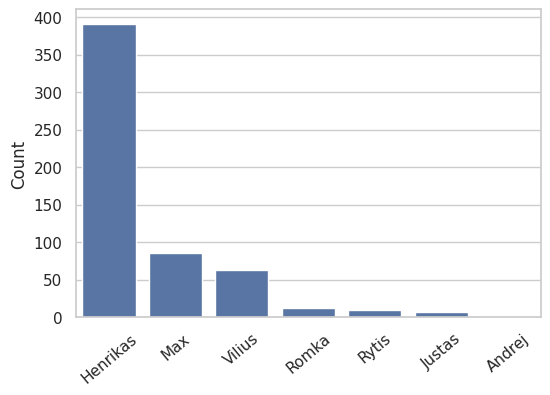

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=labels_df, x="person", order=labels_df["person"].value_counts().index, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=40)
save_plot(fig, "person_dist")
plt.show()


## Key foot distribution


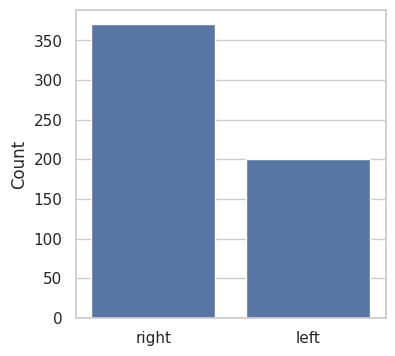

In [7]:
fig, ax = plt.subplots(figsize=(4, 4))
sns.countplot(data=labels_df, x="key_foot", order=labels_df["key_foot"].value_counts().index, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("Count")
save_plot(fig, "key_foot_dist")
plt.show()


## Clip duration distribution


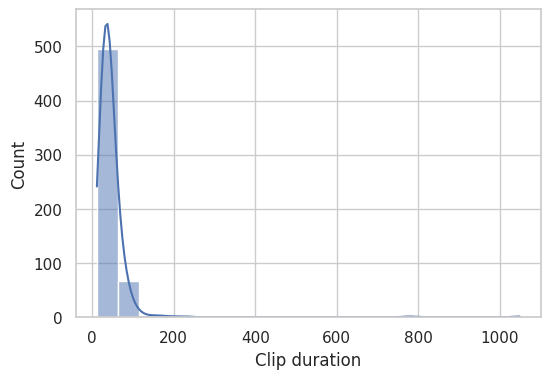

In [8]:
durations = labels_df["lead_time"].dropna()
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(durations, bins=20, kde=True, ax=ax)
ax.set_xlabel("Clip duration")
ax.set_ylabel("Count")
save_plot(fig, "clip_duration_dist")
plt.show()


## Trick vs skater heatmap


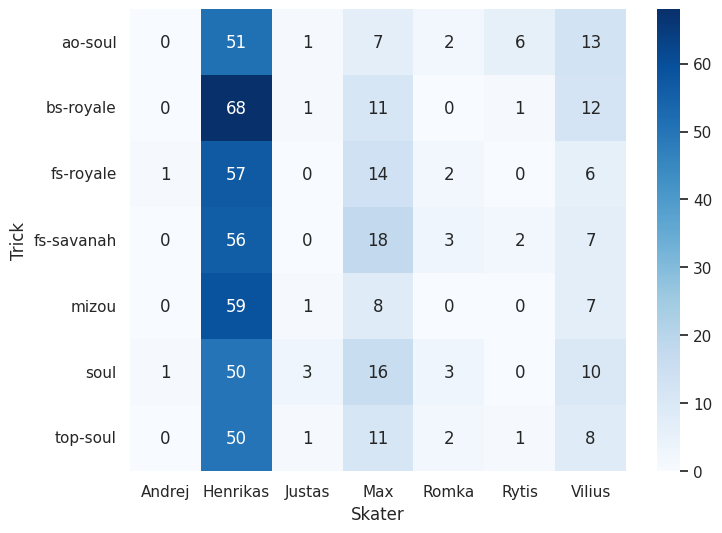

In [9]:
heatmap_df = (
    labels_df
    .groupby(["trick", "person"])
    .size()
    .reset_index(name="count")
)
heatmap_pivot = heatmap_df.pivot(index="trick", columns="person", values="count").fillna(0)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(heatmap_pivot, annot=True, fmt=".0f", cmap="Blues", ax=ax)
ax.set_xlabel("Skater")
ax.set_ylabel("Trick")
save_plot(fig, "trick_skater_heatmap")
plt.show()
